# ReduCNN Pretrained Workflow (Backend-Agnostic)

This notebook is the **single demo path** for pretrained pruning experiments:
1. Load a pretrained checkpoint (PyTorch or Keras) from `saved_models/baselines/...`
2. If missing, train a baseline once and save it
3. Prune with any registered method
4. Fine-tune (heal) and save
5. Visualize architecture, pruning process, and quality/speed metrics

In [9]:
# --- PHASE 0: BOOTLOADER (Editable Install + Python 3.12 Fix) ---
import sys, os, importlib

# 1. Python 3.12 Fix: Ensure setuptools is fresh for editable installs
!pip install -q --upgrade setuptools pip

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    project_folder_name = "activation-based-pruning"
    base_paths = ["/content/drive/Othercomputers", "/content/drive/MyDrive"]
    project_path = None

    for base in base_paths:
        if os.path.exists(base):
            for root, dirs, files in os.walk(base):
                if project_folder_name in dirs: 
                    project_path = os.path.join(root, project_folder_name); break
        if project_path: break

    if project_path:
        os.chdir(project_path)
        src_path = os.path.join(project_path, "src")
        if src_path not in sys.path: sys.path.insert(0, src_path)
        
        # 2. Restore Editable Install
        !pip install -e .
        
        # 3. Load autoreload BEFORE importing the package (3.12 stability fix)
        try:
            try:
                import imp
            except ImportError:
                from types import ModuleType
                import importlib
                imp = ModuleType('imp')
                imp.reload = importlib.reload
                sys.modules['imp'] = imp
                print("🛠️ Applied Python 3.12 'imp' shim")

            %load_ext autoreload
            %autoreload 2
            import reducnn
            print(f"✅ System Ready! ReduCNN {reducnn.__version__} loaded from: {reducnn.__file__}")
        except Exception as e: print(f"⚠️ Package import failed: {e}")
except ImportError: print("Running in Local Environment (Non-Colab)")

Mounted at /content/drive
Obtaining file:///content/drive/Othercomputers/My%20laptop/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ReduCNN (pyproject.toml) ... done
  Created wheel for ReduCNN: filename=reducnn-0.6.6-0.editable-py3-none-any.whl size=3825 sha256=fd633591c4d20aee63e4235d23560d1a5220f6c671693e8a1d0de9b4e5702452
  Stored in directory: /tmp/pip-ephem-wheel-cache-x2p66l14/wheels/95/7c/d1/d047f244a296442b073873e350be16b18b7495b817b0632d15
Successfully built ReduCNN
  Attempting uninstall: ReduCNN
    Found existing installation: ReduCNN 0.6.6
    Uninstalling ReduCNN-0.6.6:
      Successfully uninstalled ReduCNN-0.6.6


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ System Ready! ReduCNN 0.6.6 loaded from: /content/drive/Othercomputers/My laptop/activation-based-pruning/src/reducnn/__init__.py


In [11]:
import os
import sys
from pathlib import Path
from datetime import datetime
import random
import numpy as np

# Ensure local package imports work when running from repo root.
sys.path.insert(0, os.path.abspath('src'))

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset

from reducnn.backends.factory import get_adapter
from reducnn.pruner.surgeon import ReduCNNPruner
from reducnn.visualization import (
    plot_layer_sensitivity,
    plot_metrics_comparison,
    plot_training_history,
    plot_rank_correlation,
    plot_score_distributions,
    plot_decision_agreement,
    plot_feature_maps,
    plot_inference_gallery,
)
from reducnn.visualization.animator import PruningAnimator

print('Environment ready.')

Environment ready.


In [ ]:
# -----------------------------
# Minimal user controls
# -----------------------------
BACKEND = 'pytorch'            # 'pytorch' | 'keras'
MODEL_TYPE = 'resnet18'        # e.g. 'resnet18', 'vgg16', 'densenet121', 'mobilenet_v2'
PRUNE_METHOD = 'taylor'          # any bundled or registered method name
PRUNE_SCOPE = 'global'         # 'local' | 'global'
PRUNE_RATIO = 0.30             # fraction to prune

DATASET_KEY = 'cifar-10'
BATCH_SIZE = 64

AUTO_TRAIN_BASELINE_IF_MISSING = True
BASELINE_EPOCHS_IF_MISSING = 10
FINETUNE_EPOCHS = 6

RANDOM_SEED = 42
RUN_TAG = 'pretrained_demo'

COMPARE_METHODS = [PRUNE_METHOD, 'apoz', 'mean_abs_act', 'l1_norm']
EXPORT_NETWORK_HTML = True

assert BACKEND in ('pytorch', 'keras')
assert PRUNE_SCOPE in ('local', 'global')
assert 0.0 < PRUNE_RATIO < 1.0

print('Configured:')
print(f' - backend={BACKEND}')
print(f' - model={MODEL_TYPE}')
print(f' - method={PRUNE_METHOD} ({PRUNE_SCOPE}, ratio={PRUNE_RATIO:.2f})')

Configured:
 - backend=pytorch
 - model=resnet18
 - method=apoz (global, ratio=0.30)


In [13]:
# -----------------------------
# Helpers: reproducibility + paths
# -----------------------------

def _seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def _ckpt_ext(backend: str) -> str:
    return '.pth' if backend == 'pytorch' else '.weights.h5'


def _latest_file(directory: Path, suffix: str):
    if not directory.exists():
        return None
    files = sorted(directory.glob(f'*{suffix}'), key=lambda p: p.stat().st_mtime, reverse=True)
    return str(files[0]) if files else None


def _make_run_context(backend: str, dataset_key: str, model_type: str, method: str, run_tag: str):
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_id = f'{ts}_{backend}_{model_type}_{method}_{run_tag}'

    root = Path('saved_models')
    base_dir = root / 'baselines' / backend / dataset_key / model_type
    raw_dir = root / 'pruned_raw' / backend / dataset_key / model_type / method
    ft_dir = root / 'fine_tuned' / backend / dataset_key / model_type / method

    for d in (base_dir, raw_dir, ft_dir):
        d.mkdir(parents=True, exist_ok=True)

    ext = _ckpt_ext(backend)

    baseline_load = _latest_file(base_dir, ext)
    baseline_save = str(base_dir / f'{run_id}_baseline{ext}')
    raw_save = str(raw_dir / f'{run_id}_raw{ext}')
    finetuned_save = str(ft_dir / f'{run_id}_finetuned{ext}')

    out_dir = Path('outputs') / 'experiments_pretrained_workflow' / run_id
    out_dir.mkdir(parents=True, exist_ok=True)

    return {
        'run_id': run_id,
        'baseline_load': baseline_load,
        'baseline_save': baseline_save,
        'raw_save': raw_save,
        'finetuned_save': finetuned_save,
        'out_dir': out_dir,
    }


def _safe_score_maps(adapter, model, loader, methods):
    out = {}
    for m in dict.fromkeys([str(x).lower().strip() for x in methods]):
        try:
            out[m] = adapter.get_score_map(model, loader, m)
        except Exception as e:
            print(f'[score-skip] {m}: {type(e).__name__}: {e}')
    return out


_seed_everything(RANDOM_SEED)
ctx = _make_run_context(BACKEND, DATASET_KEY, MODEL_TYPE, PRUNE_METHOD, RUN_TAG)
print(f"run_id={ctx['run_id']}")
print(f"baseline_load={ctx['baseline_load']}")

run_id=20260324_210619_pytorch_resnet18_apoz_pretrained_demo
baseline_load=saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth


In [14]:
# -----------------------------
# Data + adapter + baseline model
# -----------------------------

# CIFAR-10 split: train/val/test are disjoint to avoid leakage.
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

val_size = 5000
train_size = len(full_train) - val_size
gen = torch.Generator().manual_seed(RANDOM_SEED)
train_set, val_set = random_split(full_train, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Production-style default calibration: use full training loader unless user explicitly overrides in config.
calib_loader = train_loader

input_shape = (3, 32, 32) if BACKEND == 'pytorch' else (32, 32, 3)
cfg = {
    'backend': BACKEND,
    'model_type': MODEL_TYPE,
    'input_shape': input_shape,
    'num_classes': 10,
    'lr': 3e-4,
}

adapter = get_adapter(None, cfg)
baseline_model = adapter.get_model(MODEL_TYPE, input_shape=input_shape, num_classes=10, pretrained=False)

BASELINE_CKPT_USED = ctx['baseline_load']
baseline_created = False
baseline_history = None

if BASELINE_CKPT_USED and os.path.exists(BASELINE_CKPT_USED):
    adapter.load_checkpoint(baseline_model, BASELINE_CKPT_USED)
    print(f'Loaded baseline checkpoint: {BASELINE_CKPT_USED}')
else:
    if not AUTO_TRAIN_BASELINE_IF_MISSING:
        raise FileNotFoundError('No baseline checkpoint found and AUTO_TRAIN_BASELINE_IF_MISSING=False')
    print(f'Training baseline for {BASELINE_EPOCHS_IF_MISSING} epoch(s) because no checkpoint was found...')
    baseline_history = adapter.train(
        baseline_model,
        train_loader,
        epochs=BASELINE_EPOCHS_IF_MISSING,
        val_loader=val_loader,
        name=f'{MODEL_TYPE}_baseline_{BACKEND}',
        plot=False,
    )
    adapter.save_checkpoint(baseline_model, ctx['baseline_save'])
    BASELINE_CKPT_USED = ctx['baseline_save']
    baseline_created = True
    print(f'Saved new baseline checkpoint: {BASELINE_CKPT_USED}')

if baseline_history and len(baseline_history.get('train_loss', [])) > 0:
    plot_training_history(baseline_history, title=f'{BACKEND}:{MODEL_TYPE} Baseline Training')

baseline_acc = float(adapter.evaluate(baseline_model, test_loader))
b_flops, b_params = adapter.get_stats(baseline_model, loader=test_loader)
print(f'Baseline accuracy: {baseline_acc:.2f}%')
print(f'Baseline params: {b_params/1e6:.3f}M | FLOPs: {b_flops/1e6:.3f}M')

Loaded baseline checkpoint: saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
Baseline accuracy: 87.74%
Baseline params: 11.174M | FLOPs: 557.889M


In [15]:
# -----------------------------
# Pruning phase
# -----------------------------
pruner = ReduCNNPruner(method=PRUNE_METHOD, scope=PRUNE_SCOPE, config=cfg)

pruned_model, masks, prune_time = pruner.prune(
    baseline_model,
    calib_loader,
    ratio=PRUNE_RATIO,
    adapter=adapter,
    save_pruned_path=ctx['raw_save'],
)

RAW_PRUNED_CKPT = ctx['raw_save']
pruned_acc = float(adapter.evaluate(pruned_model, test_loader))
p_flops, p_params = adapter.get_stats(pruned_model, loader=test_loader)

print(f'Raw-pruned checkpoint: {RAW_PRUNED_CKPT}')
print(f'Pruning time (surgery only): {prune_time:.3f}s')
print(f'Raw-pruned accuracy: {pruned_acc:.2f}%')
print(f'Raw-pruned params: {p_params/1e6:.3f}M | FLOPs: {p_flops/1e6:.3f}M')


--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/pytorch/cifar-10/resnet18/apoz/20260324_210619_pytorch_resnet18_apoz_pretrained_demo_raw.pth
[timer] prune took 25.12s
Raw-pruned checkpoint: saved_models/pruned_raw/pytorch/cifar-10/resnet18/apoz/20260324_210619_pytorch_resnet18_apoz_pretrained_demo_raw.pth
Pruning time (surgery only): 0.088s
Raw-pruned accuracy: 10.44%
Raw-pruned params: 5.609M | FLOPs: 343.322M


[resnet18_healing_apoz_pytorch] Epoch 1/6: 100%|██████████| 704/704 [00:35<00:00, 19.65it/s, loss=0.3602, acc=92.33%]


[val] Loss 0.1896, Acc 93.46%


[resnet18_healing_apoz_pytorch] Epoch 2/6: 100%|██████████| 704/704 [00:35<00:00, 19.85it/s, loss=0.4984, acc=96.31%]


[val] Loss 0.1802, Acc 94.12%


[resnet18_healing_apoz_pytorch] Epoch 3/6: 100%|██████████| 704/704 [00:35<00:00, 19.65it/s, loss=0.0157, acc=97.15%]


...

[val] Loss 0.2516, Acc 92.36%


[resnet18_healing_apoz_pytorch] Epoch 5/6: 100%|██████████| 704/704 [00:35<00:00, 19.56it/s, loss=0.0004, acc=99.28%]


[val] Loss 0.1550, Acc 95.44%


[resnet18_healing_apoz_pytorch] Epoch 6/6: 100%|██████████| 704/704 [00:35<00:00, 19.76it/s, loss=0.0758, acc=99.85%]


[val] Loss 0.1484, Acc 95.78%
[train] Restored best validation checkpoint (acc=95.78%).
[timer] train took 227.00s
Saved fine-tuned checkpoint: saved_models/fine_tuned/pytorch/cifar-10/resnet18/apoz/20260324_210619_pytorch_resnet18_apoz_pretrained_demo_finetuned.pth


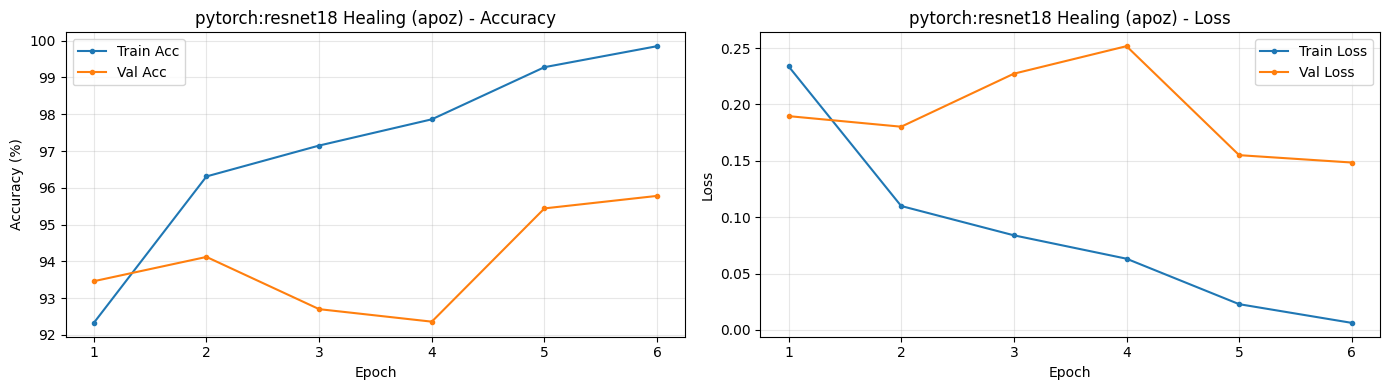

Accuracy summary:
 - Baseline: 87.74%
 - Pruned:   10.44%
 - Healed:   90.42%


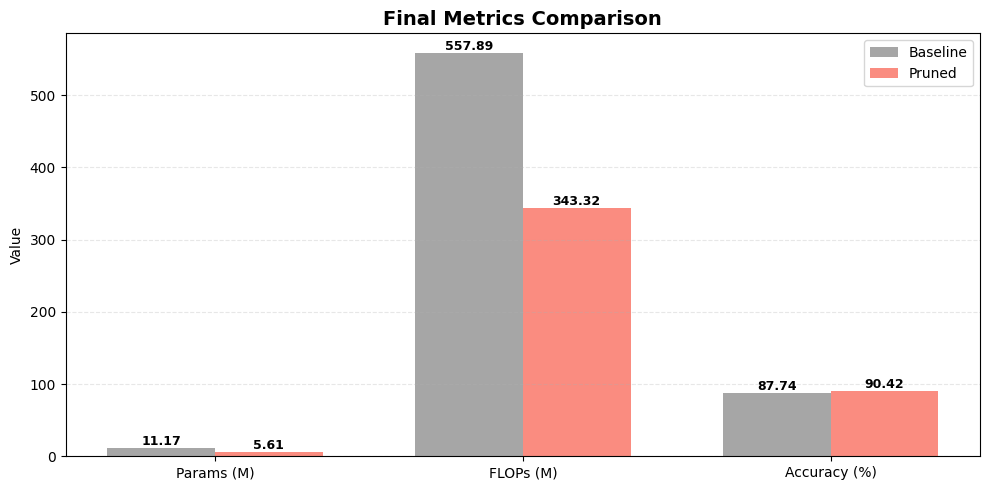

🚀 Business Impact: Model is 1.62x faster (FLOPs reduced by 38.5%).
📉 Accuracy Delta: -2.68%


In [16]:
# -----------------------------
# Fine-tuning (healing) phase
# -----------------------------
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
FINETUNED_CKPT_USED = None

if FINETUNE_EPOCHS > 0:
    history = adapter.train(
        pruned_model,
        train_loader,
        epochs=FINETUNE_EPOCHS,
        val_loader=val_loader,
        name=f'{MODEL_TYPE}_healing_{PRUNE_METHOD}_{BACKEND}',
        plot=False,
    )
    adapter.save_checkpoint(pruned_model, ctx['finetuned_save'])
    FINETUNED_CKPT_USED = ctx['finetuned_save']
    print(f'Saved fine-tuned checkpoint: {FINETUNED_CKPT_USED}')

if history and len(history.get('train_loss', [])) > 0:
    plot_training_history(history, title=f'{BACKEND}:{MODEL_TYPE} Healing ({PRUNE_METHOD})')

healed_acc = float(adapter.evaluate(pruned_model, test_loader))
h_flops, h_params = adapter.get_stats(pruned_model, loader=test_loader)

print('Accuracy summary:')
print(f' - Baseline: {baseline_acc:.2f}%')
print(f' - Pruned:   {pruned_acc:.2f}%')
print(f' - Healed:   {healed_acc:.2f}%')

plot_metrics_comparison(
    {'FLOPs': b_flops, 'Params': b_params, 'Acc': baseline_acc},
    {'FLOPs': h_flops, 'Params': h_params, 'Acc': healed_acc},
)

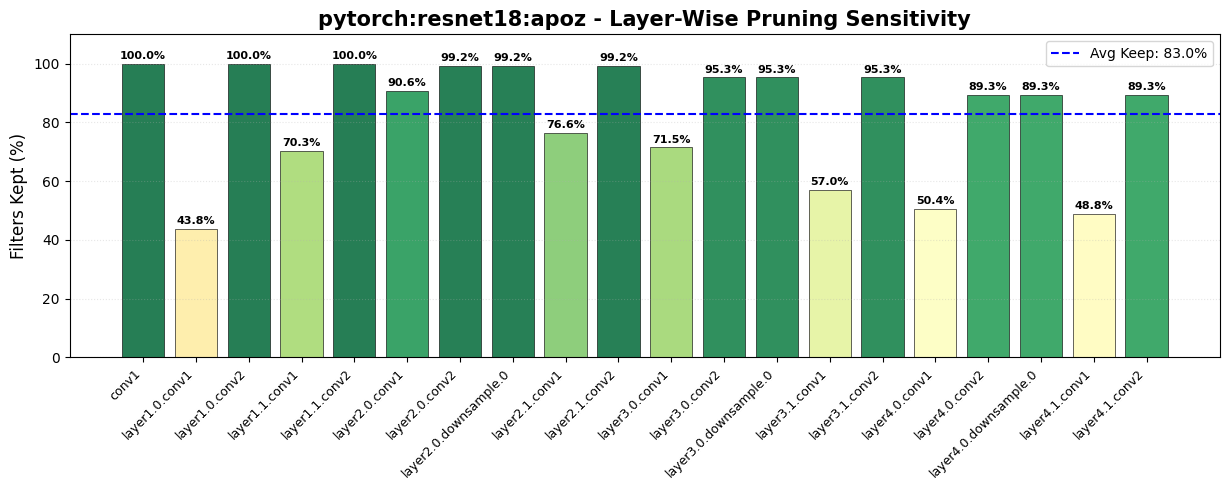

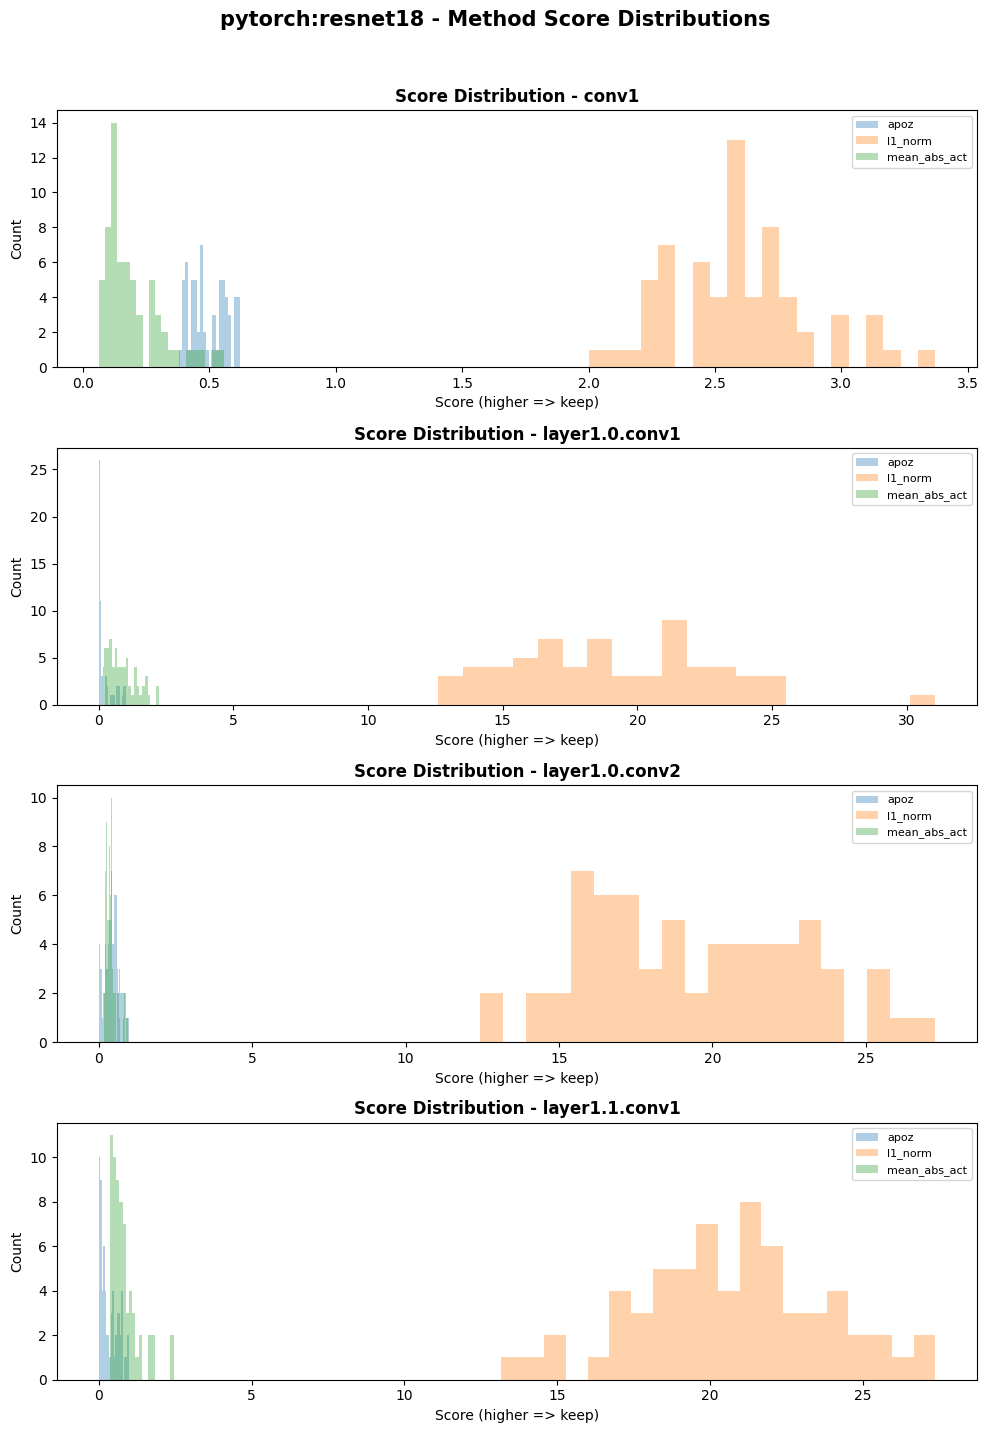

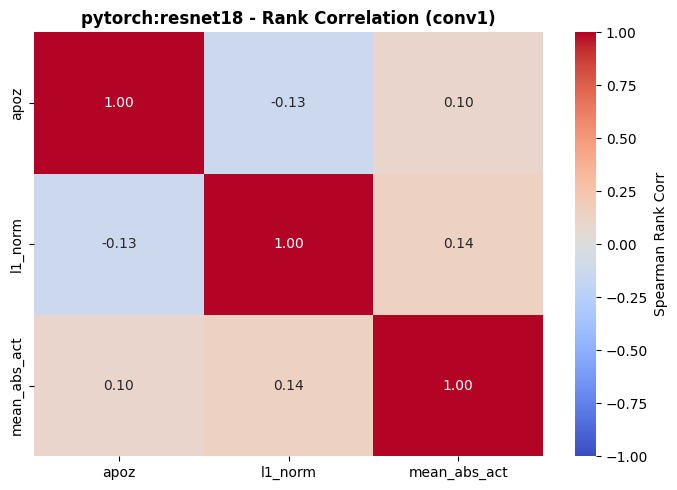

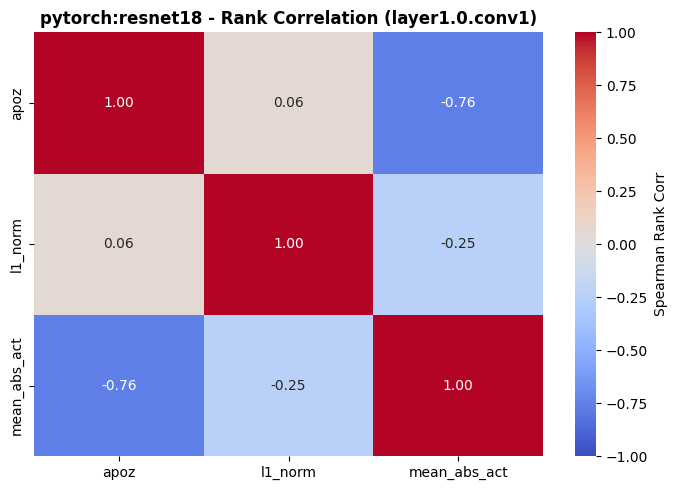

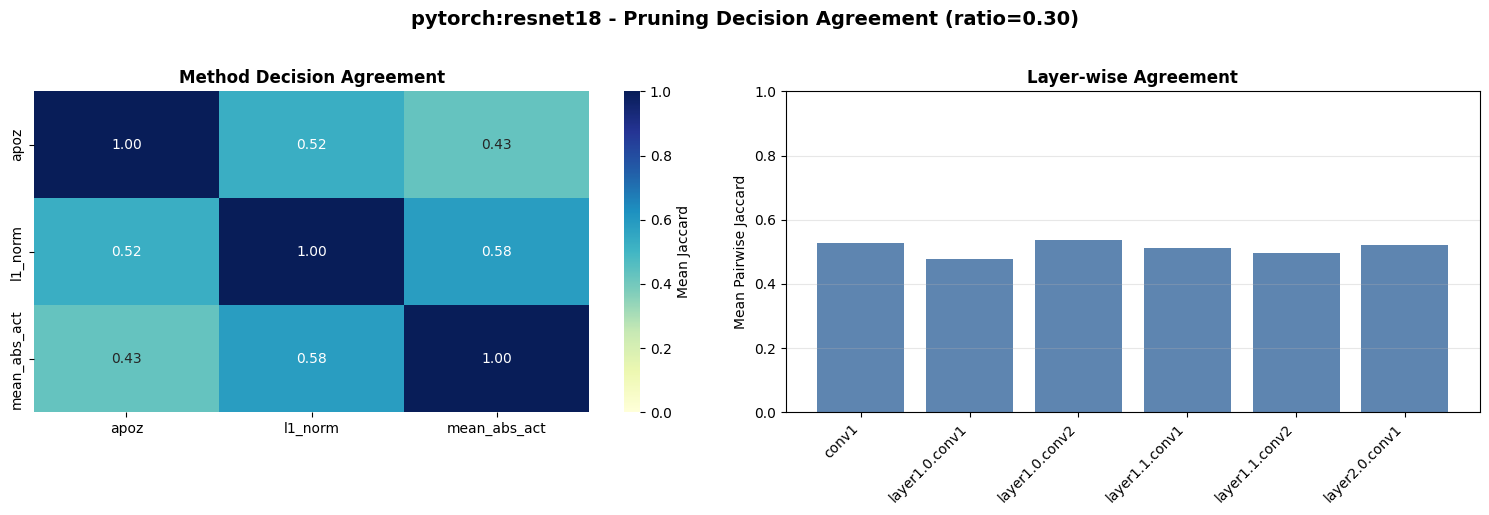

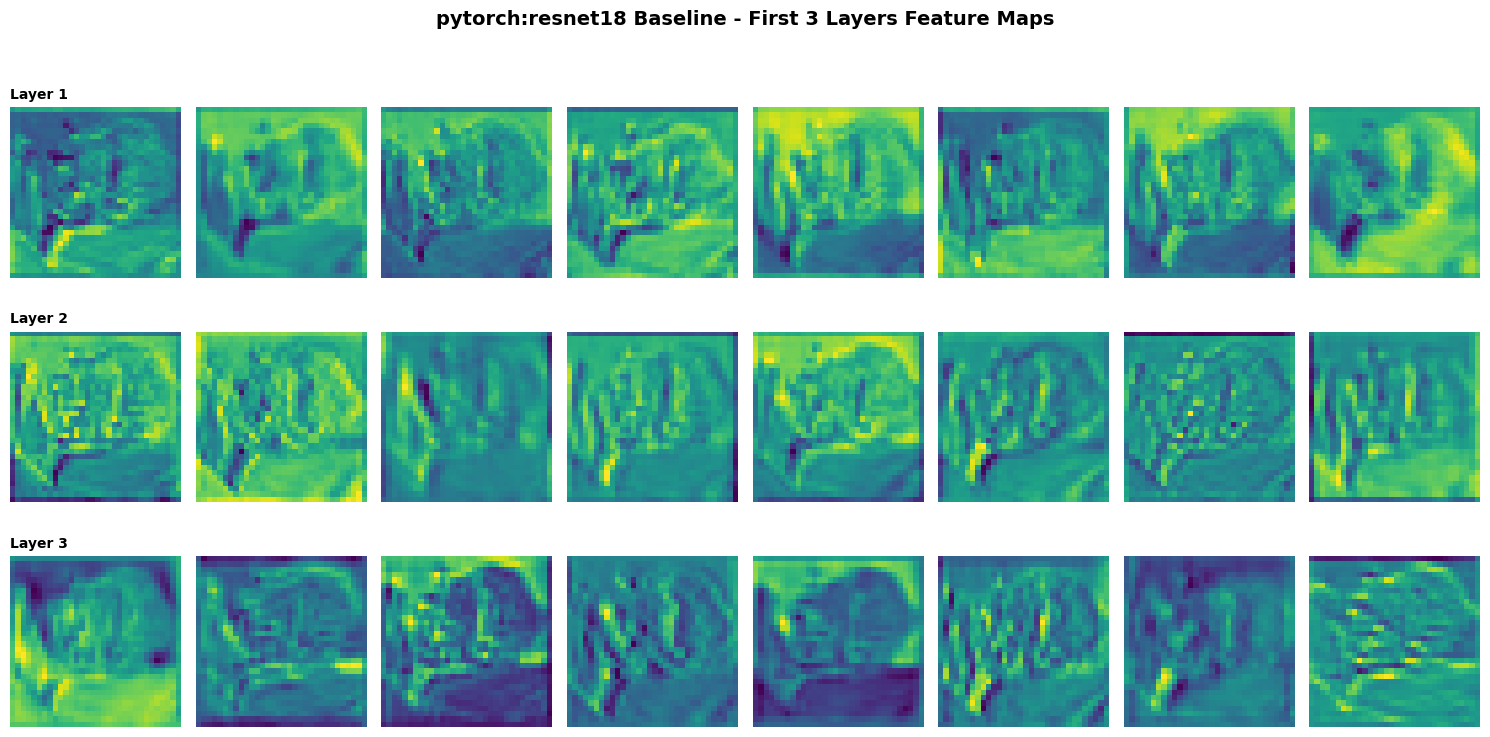

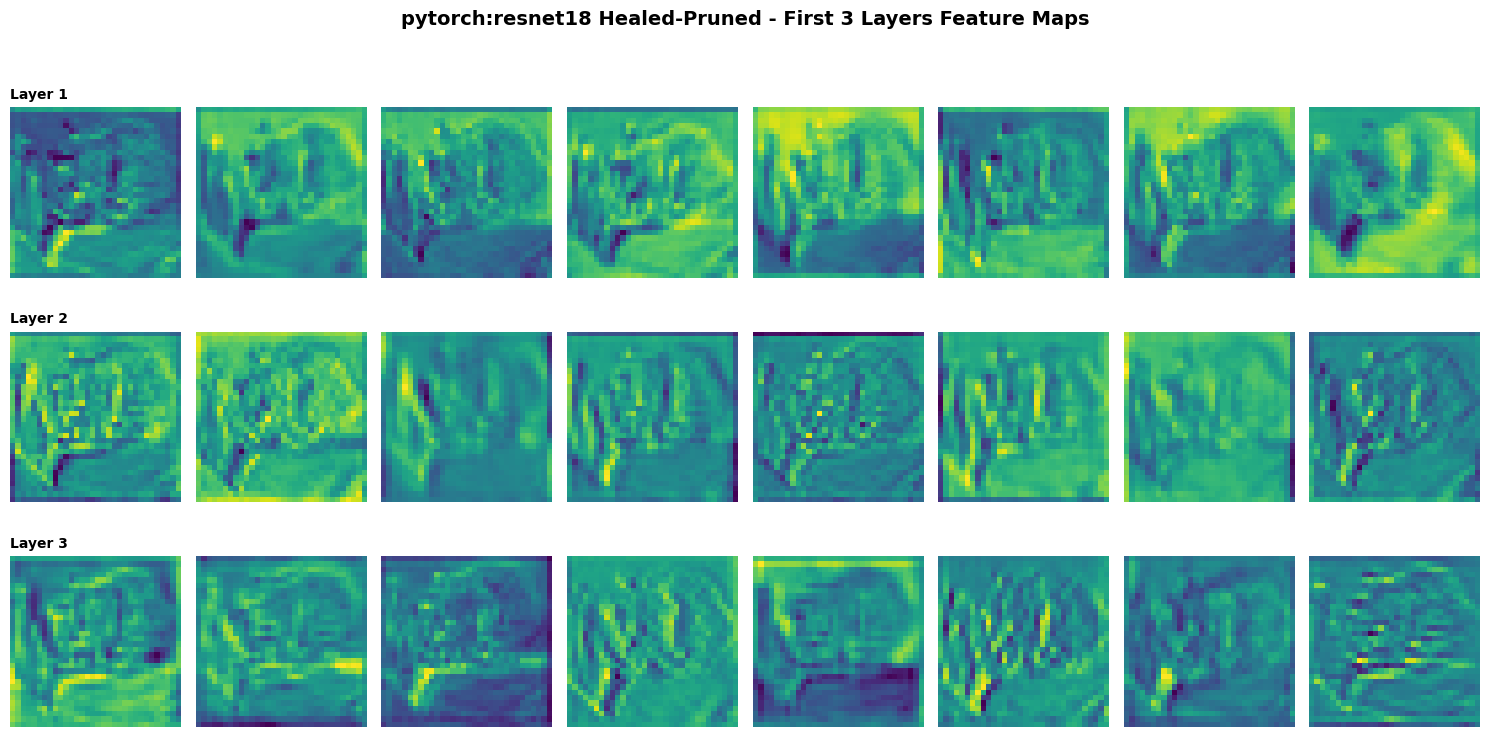

In [17]:
# -----------------------------
# Core visualizations
# -----------------------------
plot_layer_sensitivity(masks, title_prefix=f'{BACKEND}:{MODEL_TYPE}:{PRUNE_METHOD}')

score_maps = _safe_score_maps(adapter, baseline_model, calib_loader, COMPARE_METHODS)
if score_maps:
    plot_score_distributions(score_maps, title_prefix=f'{BACKEND}:{MODEL_TYPE}', max_layers=4)
    plot_rank_correlation(score_maps, title_prefix=f'{BACKEND}:{MODEL_TYPE}', max_layers=2)
    plot_decision_agreement(score_maps, ratio=PRUNE_RATIO, title_prefix=f'{BACKEND}:{MODEL_TYPE}', max_layers=6)

# Feature-map snapshots (best effort)
try:
    viz_base = adapter.get_viz_data(baseline_model, test_loader, num_layers=3)
    plot_feature_maps(viz_base, title_prefix=f'{BACKEND}:{MODEL_TYPE} Baseline')
except Exception as e:
    print(f'[viz-skip] baseline feature maps: {type(e).__name__}: {e}')

try:
    viz_pruned = adapter.get_viz_data(pruned_model, test_loader, num_layers=3)
    plot_feature_maps(viz_pruned, title_prefix=f'{BACKEND}:{MODEL_TYPE} Healed-Pruned')
except Exception as e:
    print(f'[viz-skip] pruned feature maps: {type(e).__name__}: {e}')

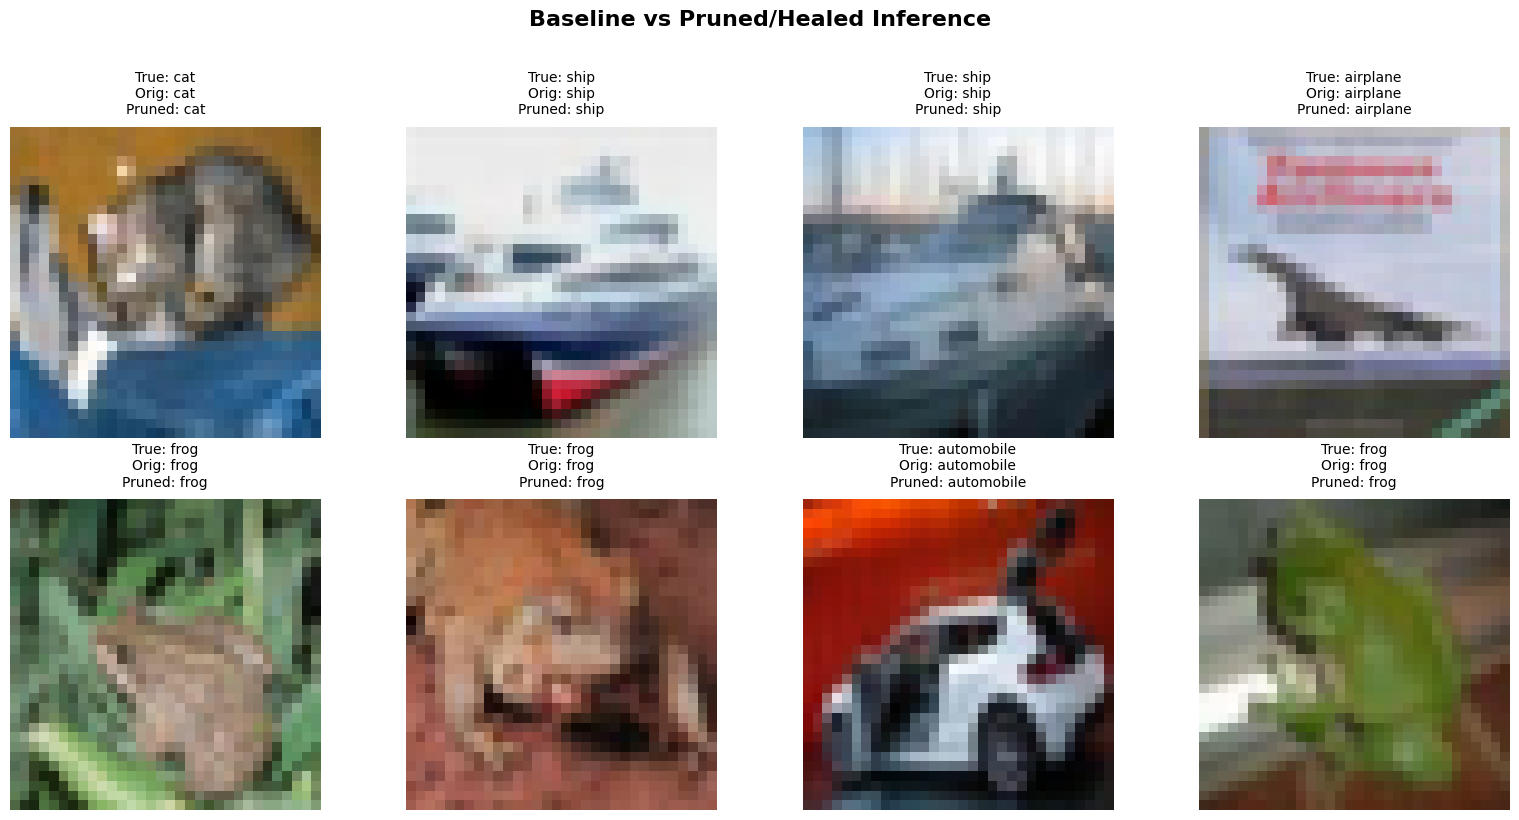

Saved graph HTML files:
 - outputs/experiments_pretrained_workflow/20260324_210619_pytorch_resnet18_apoz_pretrained_demo/candidate_discovery.html
 - outputs/experiments_pretrained_workflow/20260324_210619_pytorch_resnet18_apoz_pretrained_demo/pruning_process.html
 - outputs/experiments_pretrained_workflow/20260324_210619_pytorch_resnet18_apoz_pretrained_demo/architecture_comparison.html

Run artifacts:
 - output_dir: outputs/experiments_pretrained_workflow/20260324_210619_pytorch_resnet18_apoz_pretrained_demo
 - baseline_ckpt_used: saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
 - baseline_created: False
 - raw_pruned_ckpt: saved_models/pruned_raw/pytorch/cifar-10/resnet18/apoz/20260324_210619_pytorch_resnet18_apoz_pretrained_demo_raw.pth
 - finetuned_ckpt: saved_models/fine_tuned/pytorch/cifar-10/resnet18/apoz/20260324_210619_pytorch_resnet18_apoz_pretrained_demo_finetuned.pth


In [18]:
# -----------------------------
# Network graph visuals + inference gallery
# -----------------------------

# Build a fresh baseline model for fair side-by-side checkpointed inference.
baseline_for_inference = adapter.get_model(MODEL_TYPE, input_shape=input_shape, num_classes=10, pretrained=False)
adapter.load_checkpoint(baseline_for_inference, BASELINE_CKPT_USED)

# For pruned/healed model, use the surgically pruned instance (shape may differ from baseline).
if FINETUNED_CKPT_USED and os.path.exists(FINETUNED_CKPT_USED):
    adapter.load_checkpoint(pruned_model, FINETUNED_CKPT_USED)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_inference_gallery(
    baseline_for_inference,
    pruned_model,
    test_loader,
    num_images=8,
    class_names=class_names,
    title='Baseline vs Pruned/Healed Inference',
)

if EXPORT_NETWORK_HTML:
    animator = PruningAnimator(adapter)
    method_scores = score_maps.get(PRUNE_METHOD, None)
    if method_scores is None:
        method_scores = adapter.get_score_map(baseline_model, calib_loader, PRUNE_METHOD)

    fig_cand = animator.generate_candidate_discovery_graph(
        baseline_model,
        score_map=method_scores,
        masks=masks,
        method_name=PRUNE_METHOD,
        candidate_ratio=PRUNE_RATIO,
    )
    cand_path = animator.export_html(fig_cand, str(ctx['out_dir'] / 'candidate_discovery.html'))

    fig_proc = animator.generate_pruning_process_animation(
        baseline_model,
        score_map=method_scores,
        masks=masks,
        method_name=PRUNE_METHOD,
        candidate_ratio=PRUNE_RATIO,
    )
    proc_path = animator.export_html(fig_proc, str(ctx['out_dir'] / 'pruning_process.html'))

    fig_arch = animator.generate_architecture_comparison(
        baseline_model,
        masks=masks,
        method_name=PRUNE_METHOD,
    )
    arch_path = animator.export_html(fig_arch, str(ctx['out_dir'] / 'architecture_comparison.html'))

    print('Saved graph HTML files:')
    print(f' - {cand_path}')
    print(f' - {proc_path}')
    print(f' - {arch_path}')

print('\nRun artifacts:')
print(f" - output_dir: {ctx['out_dir']}")
print(f" - baseline_ckpt_used: {BASELINE_CKPT_USED}")
print(f" - baseline_created: {baseline_created}")
print(f" - raw_pruned_ckpt: {RAW_PRUNED_CKPT}")
print(f" - finetuned_ckpt: {FINETUNED_CKPT_USED}")